# Experiment 7: Temporal Difference Learning using TD(0) Algorithm

**Software / Tools:** Python, Gymnasium

**Focus:** how TD(0) learns the state-value function **incrementally**, one transition at a
time, rather than waiting for a full episode to end (as Monte Carlo does). Instead of
comparing two algorithms, this experiment compares the agent **before learning vs after
learning** and studies the convergence behaviour of TD(0) itself.

```
Gymnasium Environment
        |
        v
Initialize TD(0)
        |
        v
Generate Episodes
        |
        v
Observe State -> Action -> Reward -> Next State
        |
        v
TD(0) Update
        |
        v
Update Value Function
        |
        v
Repeat Episodes
        |
        v
Evaluate Learning
        |
        v
Summary Table
        |
        v
Visualizations
```


## Cell 1 — Libraries, Environment & Initialization

```
Import NumPy
Import Pandas
Import Matplotlib
Import Gymnasium
      |
      v
Create FrozenLake Environment
      |
      v
Set Random Seed
      |
      v
Define:
 - Number of episodes
 - Learning rate alpha
 - Discount factor gamma
      |
      v
Initialize value table V(s)
```

No dataset is required — everything is learned directly from interaction with the environment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
np.set_printoptions(precision=3, suppress=True)

# ---------------------------------------------------------------
# Create FrozenLake Environment
# ---------------------------------------------------------------
ENV_NAME = "FrozenLake-v1"
env = gym.make(ENV_NAME, map_name="4x4", is_slippery=False)

# ---------------------------------------------------------------
# Set Random Seed
# ---------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
env.reset(seed=SEED)
env.action_space.seed(SEED)

N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n
grid_desc = np.array([[cell.decode('utf-8') for cell in row] for row in env.unwrapped.desc])

# ---------------------------------------------------------------
# Define: episodes, learning rate, discount factor
# ---------------------------------------------------------------
EPISODES = 1000
ALPHA = 0.10     # learning rate
GAMMA = 0.99     # discount factor

# ---------------------------------------------------------------
# Initialize value table V(s)
# ---------------------------------------------------------------
V_initial = np.zeros(N_STATES)

env_params = pd.DataFrame({
    "Parameter": ["Environment", "States", "Actions", "Episodes",
                  "Learning Rate (alpha)", "Discount Factor (gamma)"],
    "Value": [ENV_NAME, N_STATES, N_ACTIONS, EPISODES, ALPHA, GAMMA]
})

print("TD(0) Environment Initialized")
print("=" * 32)
print("Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):\n")
for row in grid_desc:
    print(' '.join(list(row)))
print()
env_params


TD(0) Environment Initialized
Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):

S F F F
F H F H
F F F H
H F F G



,Parameter,Value
0,Environment,FrozenLake-v1
1,States,16
2,Actions,4
3,Episodes,1000
4,Learning Rate (alpha),0.1
5,Discount Factor (gamma),0.99


## Cell 2 — TD(0) Algorithm & Policy

```
Initialize V(s)
      |
      v
Start Episode
      |
      v
Observe Current State
      |
      v
Choose Action
      |
      v
Receive Reward
      |
      v
Observe Next State
      |
      v
Calculate TD Target
      |
      v
Calculate TD Error
      |
      v
Update V(s)
      |
      v
Move to Next State
      |
      v
Repeat Until Episode Ends
      |
      v
Repeat for All Episodes
```

**Core equation (the heart of this experiment):**

$$V(S_t) \leftarrow V(S_t) + \alpha \Big[ R_{t+1} + \gamma V(S_{t+1}) - V(S_t) \Big]$$

Actions are chosen with an epsilon-Greedy policy that decays from full exploration
(epsilon = 1.0) to mostly exploitation (epsilon = 0.05) over training. Action selection is
driven by an auxiliary SARSA-style action-value table `Q(s, a)`, but the quantity this
experiment actually studies — the state-value function `V(s)` — is updated **only** through
the pure, model-free TD(0) rule above, from transitions observed directly through Gymnasium.


In [2]:
def choose_action(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(Q[state]))


def run_td0(env, episodes, alpha, gamma, epsilon_start, epsilon_end, seed):
    rng = np.random.default_rng(seed)

    V = np.zeros(N_STATES)              # learned via pure TD(0) -- the main result
    Q = np.zeros((N_STATES, N_ACTIONS))  # auxiliary SARSA table, drives action selection only

    episode_numbers = []
    episode_rewards = []
    episode_avg_values = []
    episode_td_errors = []
    episode_steps = []

    for ep in range(episodes):
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (ep / episodes)

        # ---- Start Episode / Observe Current State ----
        state, _ = env.reset()
        action = choose_action(Q, state, epsilon, rng)

        done = False
        total_reward = 0.0
        steps = 0
        td_errors_this_episode = []

        while not done and steps < 100:
            # ---- Receive Reward / Observe Next State ----
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = None if done else choose_action(Q, next_state, epsilon, rng)

            # ---- Calculate TD Target / TD Error / Update V(s) ----
            td_target = reward + gamma * (0.0 if done else V[next_state])
            td_error = td_target - V[state]
            V[state] += alpha * td_error
            td_errors_this_episode.append(abs(td_error))

            # ---- Auxiliary SARSA update for Q(s,a) (action selection only) ----
            q_target = reward + gamma * (0.0 if done else Q[next_state, next_action])
            Q[state, action] += alpha * (q_target - Q[state, action])

            total_reward += reward
            steps += 1

            # ---- Move to Next State ----
            state = next_state
            action = next_action

        # ---- Record after every episode ----
        episode_numbers.append(ep + 1)
        episode_rewards.append(total_reward)
        episode_avg_values.append(np.mean(V))
        episode_td_errors.append(np.mean(td_errors_this_episode) if td_errors_this_episode else 0.0)
        episode_steps.append(steps)

    log = pd.DataFrame({
        "Episode": episode_numbers,
        "Total Reward": episode_rewards,
        "Average Value": episode_avg_values,
        "TD Error": episode_td_errors,
        "Steps Taken": episode_steps,
    })

    return V, Q, log


V_final, Q_final, td_log = run_td0(
    env, EPISODES, ALPHA, GAMMA, epsilon_start=1.0, epsilon_end=0.05, seed=SEED
)

print("TD(0) training complete.\n")
print("Per-episode log (first 5 / last 5 episodes):\n")
pd.concat([td_log.head(5), td_log.tail(5)])


TD(0) training complete.

Per-episode log (first 5 / last 5 episodes):



,Episode,Total Reward,Average Value,TD Error,Steps Taken
0,1,0.0,0.000000,0.000000,2
1,2,0.0,0.000000,0.000000,9
2,3,0.0,0.000000,0.000000,2
3,4,0.0,0.000000,0.000000,12
4,5,0.0,0.000000,0.000000,17
995,996,1.0,0.539806,0.018379,8
996,997,1.0,0.540486,0.018141,6
997,998,1.0,0.541156,0.017864,6
998,999,1.0,0.541760,0.016660,7
999,1000,1.0,0.542303,0.018158,8


## Cell 3 — Summary Table & Results

In [3]:
# ---------------------------------------------------------------
# Derived metrics (all calculated from the actual run above)
# ---------------------------------------------------------------
rolling_reward = td_log["Total Reward"].rolling(window=50, min_periods=1).mean()
rolling_td_error = td_log["TD Error"].rolling(window=50, min_periods=1).mean()

final_avg_value = td_log["Average Value"].iloc[-1]
average_reward = td_log["Total Reward"].tail(100).mean()        # converged performance
success_rate = (td_log["Total Reward"].tail(100) > 0).mean() * 100
final_td_error = rolling_td_error.iloc[-1]

# Convergence episode: track how the (smoothed) average state value stabilizes.
# Once its 20-episode rolling value stops changing by more than a small
# threshold and never moves again, learning is considered to have converged.
# TD error itself never fully reaches zero here because epsilon never reaches
# zero (some exploration noise remains by design), so convergence is judged
# from the value estimates rather than the noisy per-step TD error.
rolling_avg_value = td_log["Average Value"].rolling(window=20, min_periods=1).mean()
value_diffs = rolling_avg_value.diff().abs()

WARMUP_EPISODES = 100
THRESHOLD = 0.001
below_threshold = value_diffs < THRESHOLD
convergence_episode = EPISODES
for i in range(WARMUP_EPISODES, len(below_threshold)):
    if below_threshold.iloc[i:].all():
        convergence_episode = i + 1
        break

summary_table = pd.DataFrame({
    "Metric": ["Total Episodes", "Learning Rate (alpha)", "Discount Factor (gamma)",
               "Final Average Value", "Average Reward", "Success Rate",
               "Final TD Error", "Convergence Episode"],
    "Result": [EPISODES, f"{ALPHA:.2f}", f"{GAMMA:.2f}", f"{final_avg_value:.3f}",
               f"{average_reward:.2f}", f"{success_rate:.1f}%", f"{final_td_error:.4f}",
               convergence_episode]
})

print("Summary Table\n")
display(summary_table)

# ---------------------------------------------------------------
# Selected states: initial vs final value
# ---------------------------------------------------------------
selected_states = [0, 1, 2, 3]
state_change_table = pd.DataFrame({
    "State": selected_states,
    "Initial Value": [f"{V_initial[s]:.2f}" for s in selected_states],
    "Final Value": [f"{V_final[s]:.2f}" for s in selected_states],
    "Change": [f"{V_final[s] - V_initial[s]:+.2f}" for s in selected_states],
})

print("\nSelected State Values (Before vs After Learning)\n")
state_change_table


Summary Table



,Metric,Result
0,Total Episodes,1000
1,Learning Rate (alpha),0.10
2,Discount Factor (gamma),0.99
3,Final Average Value,0.542
4,Average Reward,0.91
5,Success Rate,91.0%
6,Final TD Error,0.0488
7,Convergence Episode,943



Selected State Values (Before vs After Learning)



,State,Initial Value,Final Value,Change
0,0,0.00,0.85,+0.85
1,1,0.00,0.48,+0.48
2,2,0.00,0.66,+0.66
3,3,0.00,0.24,+0.24


## Cell 4 — Results / Interpretation

In [4]:
print("=" * 40)
print("        TD(0) LEARNING RESULTS")
print("=" * 40)
print()
print(f"Episodes              : {EPISODES}")
print(f"Average Reward        : {average_reward:.2f}")
print(f"Success Rate          : {success_rate:.1f} %")
print(f"Final Average Value   : {final_avg_value:.3f}")
print(f"Convergence Episode   : {convergence_episode}")
print()
print("Observation:")
print("The TD(0) algorithm gradually improves")
print("the state-value estimates through")
print("incremental updates from observed")
print("transitions.")


        TD(0) LEARNING RESULTS

Episodes              : 1000
Average Reward        : 0.91
Success Rate          : 91.0 %
Final Average Value   : 0.542
Convergence Episode   : 943

Observation:
The TD(0) algorithm gradually improves
the state-value estimates through
incremental updates from observed
transitions.


## Cell 5 — Visualizations

Three figures only:

1. **Learning Curve** — smoothed average reward per episode (learning performance)
2. **Value Function Convergence** — average state value per episode (value estimation)
3. **TD Error** — smoothed TD error per episode (learning stability)


### Visualization 1: Learning Curve

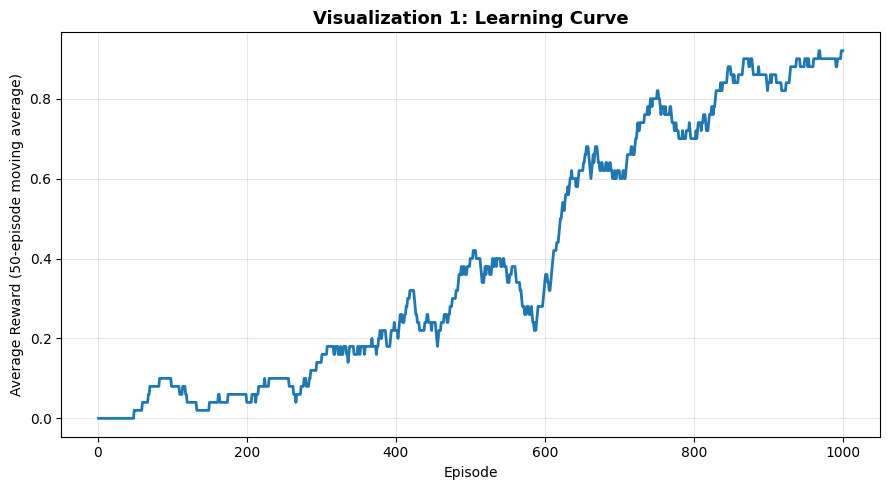

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(td_log["Episode"], rolling_reward, color="tab:blue", linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Average Reward (50-episode moving average)")
ax.set_title("Visualization 1: Learning Curve", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Visualization 2: Value Function Convergence

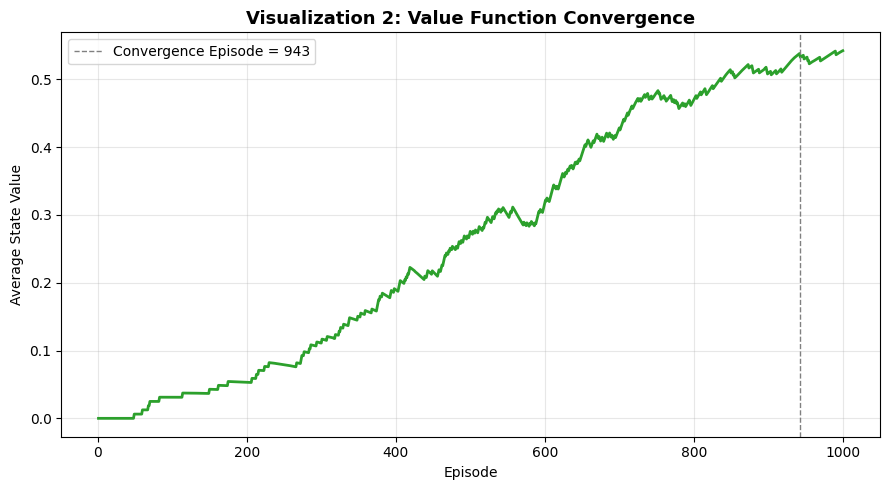

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(td_log["Episode"], td_log["Average Value"], color="tab:green", linewidth=2)

ax.axvline(convergence_episode, color="gray", linestyle="--", linewidth=1,
           label=f"Convergence Episode = {convergence_episode}")

ax.set_xlabel("Episode")
ax.set_ylabel("Average State Value")
ax.set_title("Visualization 2: Value Function Convergence", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Visualization 3: TD Error

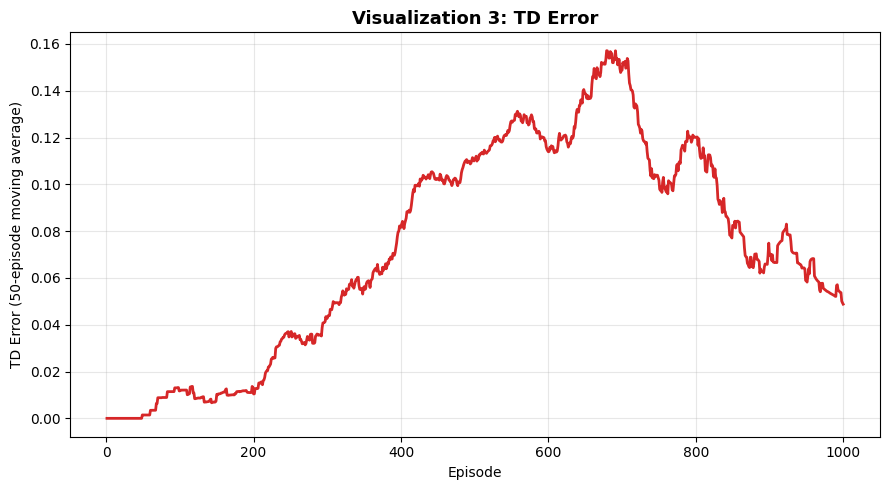

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(td_log["Episode"], rolling_td_error, color="tab:red", linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("TD Error (50-episode moving average)")
ax.set_title("Visualization 3: TD Error", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
